# Stuttering Detection: Linear Classification Analysis
**Course**: CS204T (Artificial Intelligence)  
**Team**: 18  
**Focus**: Logistic Regression vs. The Perceptron

---

## Step 1: Environment & Configuration

In [1]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data import DataManager
from src.models import LogisticModel, PerceptronModel
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
from sklearn.decomposition import PCA

# ==========================================
# CONFIGURATION
# ==========================================
SAMPLE_LIMIT = None
STRICT_LABELS = True
RANDOM_SEED = 42
FEATURE_DIR = "data/features"
AUDIO_DIR = "Stuttering Events in Podcasts Dataset/clips"  # Path to raw audio
CSV_PATHS = [
    "Stuttering Events in Podcasts Dataset/SEP-28k_labels.csv",
    "Stuttering Events in Podcasts Dataset/fluencybank_labels.csv"
]
# ==========================================

## Step 2: Operational Mode for Data Extraction

In [2]:
# Operational Flags
SKIP_EXTRACTION = True
FORCE_EXTRACT = False
CLEAN_START = False
NUM_CLIPS_TO_EXTRACT = None

if not SKIP_EXTRACTION or CLEAN_START or FORCE_EXTRACT:
    from src.extractors import WavLMExtractor
    extractor = WavLMExtractor("microsoft/wavlm-base")
    label_dict = DataManager.generate_label_dict(CSV_PATHS, filter_quality=True, strict=STRICT_LABELS)
    extractor.extract_from_dir(AUDIO_DIR, output_dir=FEATURE_DIR, label_dict=None, limit=NUM_CLIPS_TO_EXTRACT, random_sample=True)
else:
    print("[System] Skipping extraction. Using existing data on disk.")

[System] Skipping extraction. Using existing data on disk.


## Step 3: Data Loading and Preparation (Smart Load Optimized)

In [3]:
label_dict = DataManager.generate_label_dict(CSV_PATHS, filter_quality=True, strict=STRICT_LABELS)
manager = DataManager(None, None)

X, y = manager.load_from_folders("non_stutter", os.path.join(FEATURE_DIR, "disfluent"), limit=SAMPLE_LIMIT, label_dict=None)

X_train, X_val, X_test, y_train, y_val, y_test = manager.get_splits(test_size=0.15, val_size=0.15)
X_train_bal, y_train_bal = manager.balance_data(X_train, y_train, strategy="oversample")

# PREPROCESS (Fit on train, transform on val/test)
X_train_final = manager.preprocess(X_train_bal, method="standard", fit=True)
X_val_final = manager.preprocess(X_val, fit=False)
X_test_final = manager.preprocess(X_test, fit=False)

print(f"Data Loaded: {len(X)} samples.")
manager.analyze_distribution()

[DataManager] Quality Filter: Removed 3938 low-quality samples.
[DataManager] Strict Filter: Kept 16109 high-agreement samples (Removed 12274 ambiguous samples).
[DataManager] Strict Filtering: Kept 14452 high-agreement samples (Discarded 11361 ambiguous samples).
Data Loaded: 14452 samples.
--- Data Distribution ---
Fluent (0): 7784 (53.9%)
Disfluent (1): 6668 (46.1%)
Total: 14452


## Step 4: Model 1 - Logistic Regression (Baseline)

In [4]:
log_model = LogisticModel("Logistic_Baseline")
log_model.train(X_train_final, y_train_bal)
print("Evaluating Logistic Baseline:")
log_model.evaluate(X_test_final, y_test)

[Model: Logistic_Baseline] Initialized.
[Logistic_Baseline] Training on 10896 samples...
Evaluating Logistic Baseline:

--- Evaluation: Logistic_Baseline ---
Accuracy: 0.8178
Precision: 0.8135
Recall: 0.7850
F1: 0.7990

Confusion Matrix (Binary):
               Predicted: Fluent(0)  Predicted: Stutter(1)
True: Fluent(0)      988             180            
True: Stutter(1)     215             785            


{'accuracy': 0.8178044280442804,
 'precision': 0.8134715025906736,
 'recall': 0.785,
 'f1': 0.7989821882951654,
 'confusion_matrix': array([[988, 180],
        [215, 785]])}

## Step 5: Model 2 - The Perceptron (Baseline)

In [5]:
perc_model = PerceptronModel("Perceptron_Baseline")
perc_model.train(X_train_final, y_train_bal)
print("Evaluating Perceptron Baseline:")
perc_model.evaluate(X_test_final, y_test)

[Model: Perceptron_Baseline] Initialized.
[Perceptron_Baseline] Training on 10896 samples...
Evaluating Perceptron Baseline:

--- Evaluation: Perceptron_Baseline ---
Accuracy: 0.7399
Precision: 0.7198
Recall: 0.7140
F1: 0.7169

Confusion Matrix (Binary):
               Predicted: Fluent(0)  Predicted: Stutter(1)
True: Fluent(0)      890             278            
True: Stutter(1)     286             714            


{'accuracy': 0.7398523985239852,
 'precision': 0.719758064516129,
 'recall': 0.714,
 'f1': 0.7168674698795181,
 'confusion_matrix': array([[890, 278],
        [286, 714]])}

## Step 6: Optimized Hyperparameter Tuning (Natural Validation Set)
Searching for the best configuration using a `PredefinedSplit`. This tunes the model against the **natural, unbalanced validation set** to ensure real-world robustness.

In [6]:
print("--- [STARTING LINEAR HYPERTUNING] ---")

# 1. Combine Train + Val and create split indices
X_combined = np.vstack((X_train_final, X_val_final))
y_combined = np.hstack((y_train_bal, y_val))
test_fold = np.hstack((
    np.full(len(X_train_final), -1), # -1 = training indices
    np.full(len(X_val_final), 0)     # 0 = validation indices (the 'fold' to test on)
))
pds = PredefinedSplit(test_fold=test_fold)

# 2. Tune Logistic Regression
# Expanded to include ElasticNet (best of both worlds)
log_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100], 
    'solver': ['saga'], # 'saga' is required for elasticnet
    'penalty': ['l1', 'l2', 'elasticnet'],
    'l1_ratio': [0.5], # Only used if penalty is elasticnet
    'max_iter': [2000]
}
gs_log = GridSearchCV(LogisticRegression(random_state=RANDOM_SEED), log_grid, cv=pds, scoring='accuracy', n_jobs=-1)
gs_log.fit(X_combined, y_combined)
# Data Collection Export
pd.DataFrame(gs_log.cv_results_).to_csv("reports/logistic_hypertuning_benchmarks.csv", index=False)
print(f"Best LogReg: {gs_log.best_params_} (Val Accuracy: {gs_log.best_score_:.4f})")

# 3. Tune Perceptron
# Expanded learning rate (eta0) and alpha range
perc_grid = {
    'eta0': [0.0001, 0.001, 0.01, 0.1, 1.0], 
    'penalty': ['l2', 'l1', 'elasticnet'], 
    'alpha': [1e-5, 1e-4, 1e-3, 0.01], 
    'max_iter': [2000]
}
gs_perc = GridSearchCV(Perceptron(random_state=RANDOM_SEED), perc_grid, cv=pds, scoring='accuracy', n_jobs=-1)
gs_perc.fit(X_combined, y_combined)
# Data Collection Export
pd.DataFrame(gs_perc.cv_results_).to_csv("reports/perceptron_hypertuning_benchmarks.csv", index=False)
print(f"Best Perceptron: {gs_perc.best_params_} (Val Accuracy: {gs_perc.best_score_:.4f})")

--- [STARTING LINEAR HYPERTUNING] ---


KeyboardInterrupt: 

## Step 7: Final Insights & Reporting (Visuals)
We compare error patterns for both models using heatmaps.

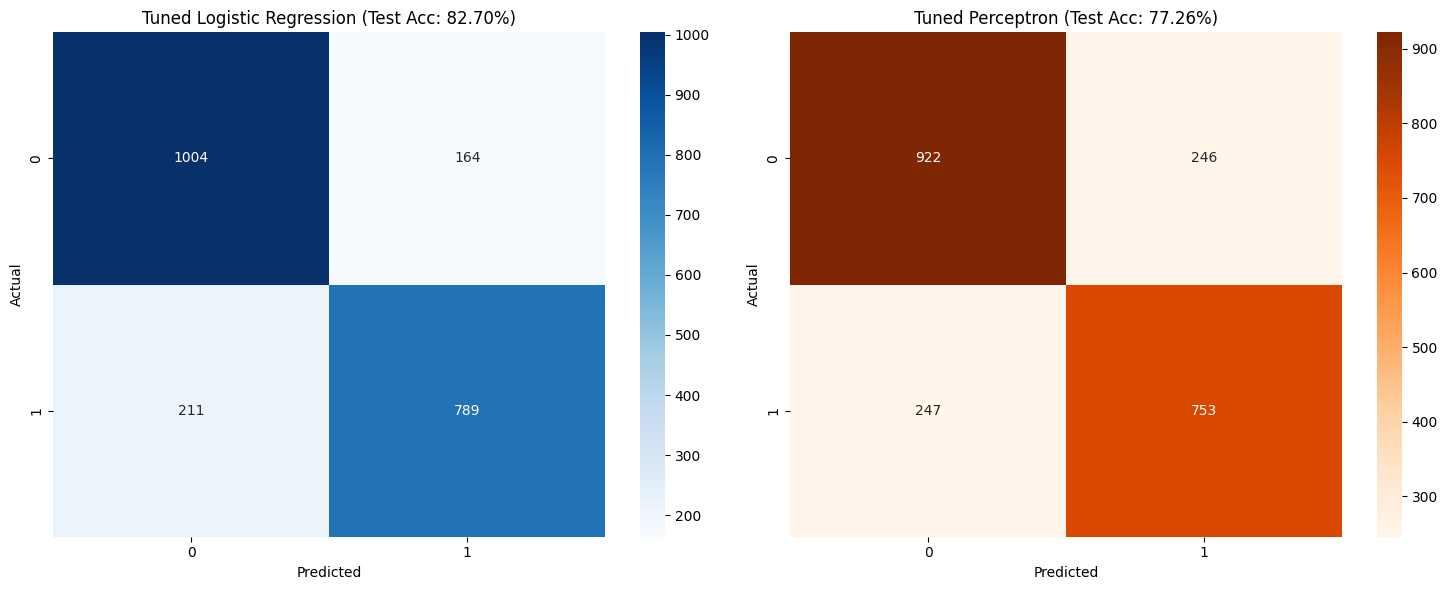

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Logistic Regression Prediction & Accuracy
y_pred_log = gs_log.best_estimator_.predict(X_test_final)
test_acc_log = accuracy_score(y_test, y_pred_log)
cm_log = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f"Tuned Logistic Regression (Test Acc: {test_acc_log:.2%})")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# 2. Perceptron Prediction & Accuracy
y_pred_perc = gs_perc.best_estimator_.predict(X_test_final)
test_acc_perc = accuracy_score(y_test, y_pred_perc)
cm_perc = confusion_matrix(y_test, y_pred_perc)

sns.heatmap(cm_perc, annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title(f"Tuned Perceptron (Test Acc: {test_acc_perc:.2%})")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


## Step 8: Comparative Decision Boundaries
Using 2D PCA to show the 'Line in the Sand' for both linear classifiers.

/home/anshuman139/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/anshuman139/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/anshuman139/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l2 with l1_ratio=0.5. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


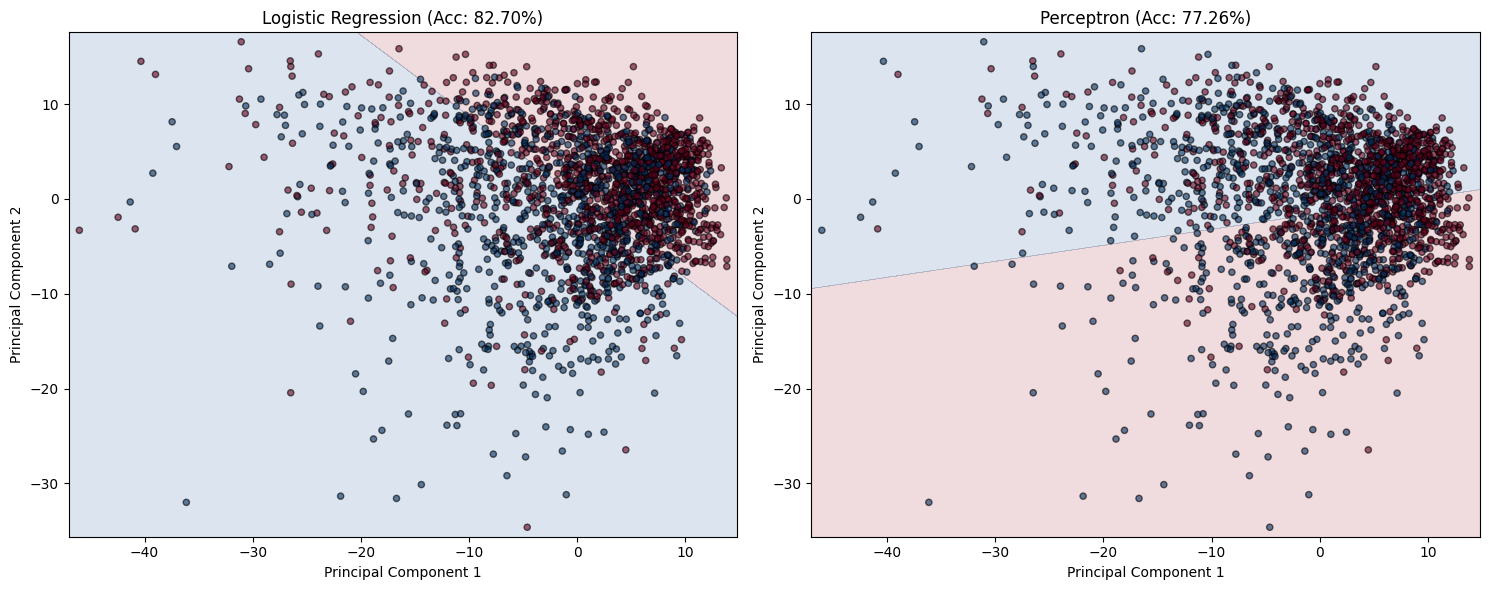

In [ ]:
# Decision Boundary Visualization
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_train_pca = pca.fit_transform(X_train_final)
X_test_pca = pca.transform(X_test_final)

# Mesh grid
h = .02
x_min, x_max = X_test_pca[:, 0].min() - 1, X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

def plot_linear_2d(model_type, params, ax, title, real_preds, real_acc):
    model_2d = model_type(**params, random_state=RANDOM_SEED)
    model_2d.fit(X_train_pca, y_train_bal)
    Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap='RdBu', alpha=0.15)
    ax.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=real_preds,
              cmap='RdBu', alpha=0.6, edgecolors='k', s=20)
    ax.set_title(f'{title} (Acc: {real_acc:.2%})')
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')

plot_linear_2d(LogisticRegression, gs_log.best_params_, axes[0],
               'Logistic Regression', y_pred_log, test_acc_log)
plot_linear_2d(Perceptron, gs_perc.best_params_, axes[1],
               'Perceptron', y_pred_perc, test_acc_perc)

plt.tight_layout()
plt.show()

## Step 9: Save Best Models
Persist the best estimators for future comparison and deployment.

In [ ]:
import joblib
os.makedirs("models", exist_ok=True)
joblib.dump(gs_log.best_estimator_, "models/logistic_regression_best.pkl")
joblib.dump(gs_perc.best_estimator_, "models/perceptron_best.pkl")
print("[System] Best linear models saved to \"models/\" directory.")

[System] Best linear models saved to "models/" directory.


In [ ]:
# Extract metrics for the Leaderboard
linear_final_accuracy = accuracy_score(y_test, gs_log.best_estimator_.predict(X_test_final))
linear_final_f1 = f1_score(y_test, gs_log.best_estimator_.predict(X_test_final))

print("--- [FINAL BENCHMARKING RESULTS] ---")
print(f"Optimal Logistic Regression Accuracy: {linear_final_accuracy:.4f}")
print(f"Optimal Logistic Regression F1: {linear_final_f1:.4f}")
print(f"[System] Trials exported to 'reports/' for documentation.")


--- [FINAL BENCHMARKING RESULTS] ---
Optimal Logistic Regression Accuracy: 0.8270
Optimal Logistic Regression F1: 0.8080
[System] Trials exported to 'reports/' for documentation.


/home/anshuman139/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/anshuman139/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/anshuman139/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l2 with l1_ratio=0.5. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


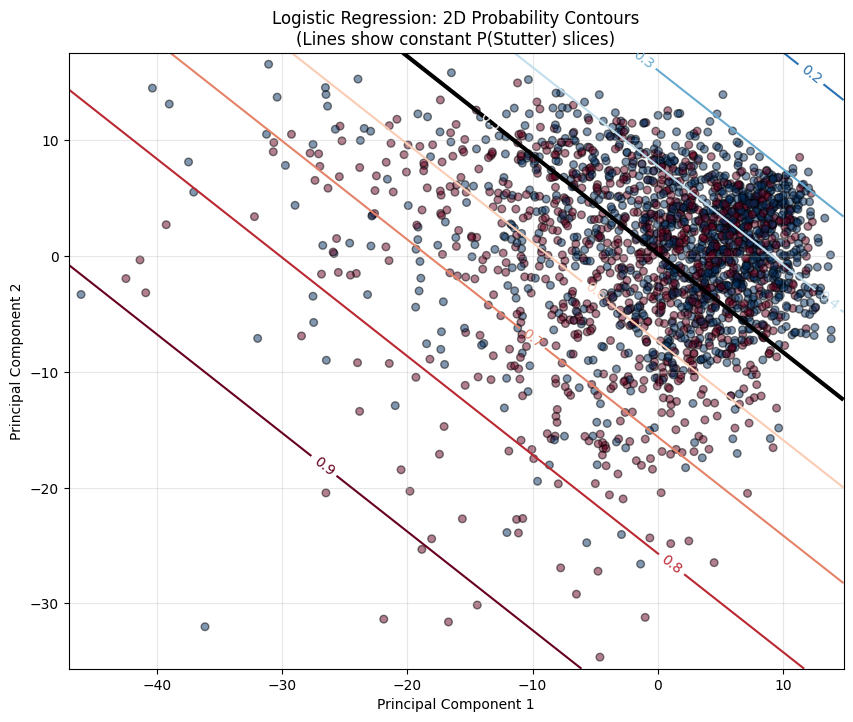

In [ ]:
# --- STEP 10: 2D CONTOUR PLOT (PROBABILITY SLICES) ---
# This visualizes the "softness" of the Logistic Regression boundary

# 1. Fit the 2D proxy for visualization
log_2d = LogisticRegression(**gs_log.best_params_, random_state=RANDOM_SEED)
log_2d.fit(X_train_pca, y_train_bal)

# 2. Generate probability surface
# xx, yy and X_test_pca come from the previous Decision Boundary cell
Z_prob = log_2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

plt.figure(figsize=(10, 8))

# 3. Plot the constant Z slices (The Contours)
# We plot lines for every 0.1 change in probability
contours = plt.contour(xx, yy, Z_prob, levels=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9], 
                       cmap='RdBu_r', linewidths=1.5)

# Label the slices with their probability values
plt.clabel(contours, inline=True, fontsize=10, fmt='%.1f')

# 4. Highlight the 0.5 Decision Boundary (The "slice" where the model switches classes)
plt.contour(xx, yy, Z_prob, levels=[0.5], colors='black', linewidths=3)

# 5. Scatter the data points
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='RdBu_r', 
            edgecolors='k', alpha=0.5, s=30)

plt.title("Logistic Regression: 2D Probability Contours\n(Lines show constant P(Stutter) slices)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# --- STEP 11: PERCEPTRON DISTANCE CONTOURS ---
# Since Perceptron has no probabilities, we plot constant DISTANCE slices

# 1. Fit the 2D proxy for visualization
perc_2d = Perceptron(**gs_perc.best_params_, random_state=RANDOM_SEED)
perc_2d.fit(X_train_pca, y_train_bal)

# 2. Generate the Distance Surface
# Uses the same meshgrid (xx, yy) from previous cells
Z_dist = perc_2d.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(10, 8))

# 3. Plot the constant Z slices (Distance Contours)
contours = plt.contour(xx, yy, Z_dist, levels=15, cmap='RdBu_r', linewidths=1.5)

# Label the distances
plt.clabel(contours, inline=True, fontsize=10, fmt='%.1f')

# 4. Highlight the 0.0 Boundary (The thick line where classes flip)
plt.contour(xx, yy, Z_dist, levels=[0.0], colors='black', linewidths=3)

# 5. Scatter the test data
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='RdBu_r', 
            edgecolors='k', alpha=0.5, s=30)

plt.title("Perceptron: 2D Distance Contours\n(Lines show constant distance from the hyperplane)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()
